In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [32]:
dos = pd.read_csv("DOS.dat", delim_whitespace=True, comment="#", header=None)
print(dos.head())

    0        1        2        3         4         5         6         7   \
0  0.0  0.36892  0.11995  0.12026  0.037578  0.036995  0.027023  0.027109   
1  0.1  0.36907  0.12006  0.12037  0.037583  0.037005  0.026979  0.027068   
2  0.2  0.36923  0.12018  0.12048  0.037588  0.037014  0.026936  0.027027   
3  0.3  0.36938  0.12029  0.12060  0.037592  0.037024  0.026894  0.026987   
4  0.4  0.36953  0.12040  0.12071  0.037596  0.037033  0.026851  0.026947   

             8             9             10            11            12  \
0  2.738900e-07  2.737800e-07  2.382500e-07  2.380300e-07  1.573600e-07   
1  2.739300e-07  2.738200e-07  2.382800e-07  2.380600e-07  1.573700e-07   
2  2.739700e-07  2.738600e-07  2.383100e-07  2.380900e-07  1.573900e-07   
3  2.740100e-07  2.738900e-07  2.383400e-07  2.381200e-07  1.574000e-07   
4  2.740400e-07  2.739300e-07  2.383700e-07  2.381600e-07  1.574200e-07   

             13  
0  1.572100e-07  
1  1.572200e-07  
2  1.572400e-07  
3  1.572600e-0

/tmp/ipykernel_1662924/3760977832.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dos = pd.read_csv("DOS.dat", delim_whitespace=True, comment="#", header=None)


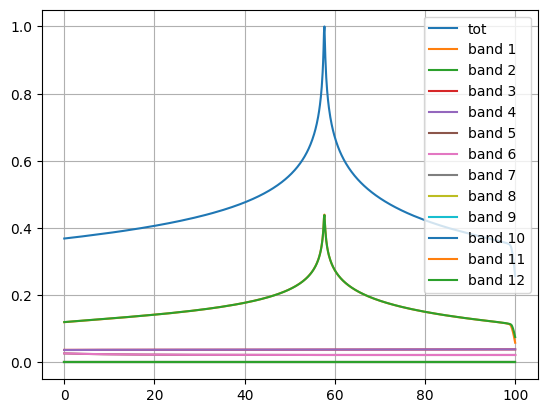

In [33]:
plt.plot(dos[0], dos[1], label = "tot")
for i in range(2, dos.shape[1]):
    plt.plot(dos[0], dos[i], label = f"band {i-1}")
plt.legend()
plt.grid()
plt.show()

In [34]:
# Read heatmap data
i = 1
j = 1
gamma_map = pd.read_csv(f"GammaK_i{i}_j{j}_band1.dat", delim_whitespace=True, comment="#", header=None)


/tmp/ipykernel_1662924/1069992980.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  gamma_map = pd.read_csv(f"GammaK_i{i}_j{j}_band1.dat", delim_whitespace=True, comment="#", header=None)


0


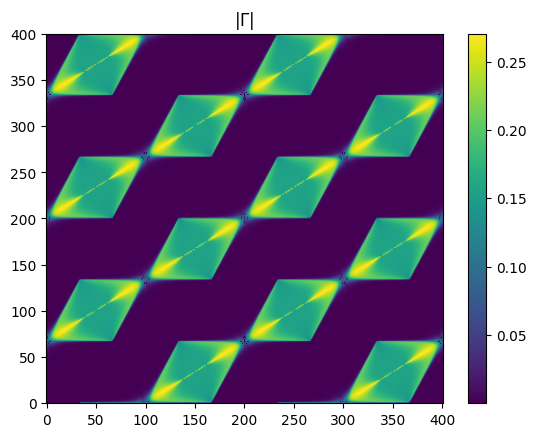

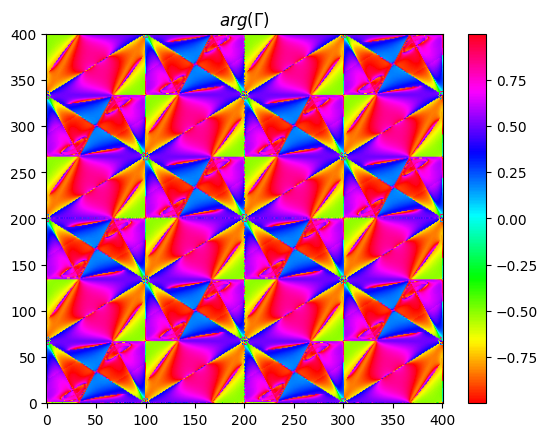

In [35]:
gamma_map['norm_gamma'] = np.sqrt(gamma_map[2]**2 + gamma_map[3]**2)
gamma_map['phase_gamma'] = (np.arctan2(gamma_map[3], gamma_map[2]))/ np.pi

pivot = gamma_map.pivot(index=1, columns=0, values='norm_gamma')
print(pivot.isna().sum().sum())  # Count total NaNs
plt.title(r"$|\Gamma|$")
plt.imshow(pivot, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar()
plt.show()


pivot = gamma_map.pivot(index=1, columns=0, values='phase_gamma')
plt.title(r"$arg(\Gamma)$")
plt.imshow(pivot, aspect='auto', origin='lower', cmap='hsv')
plt.colorbar()
plt.show()


0


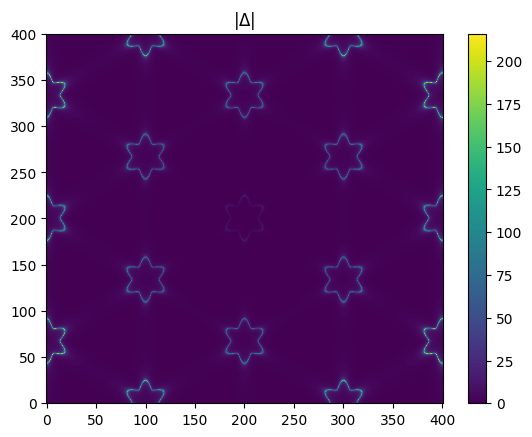

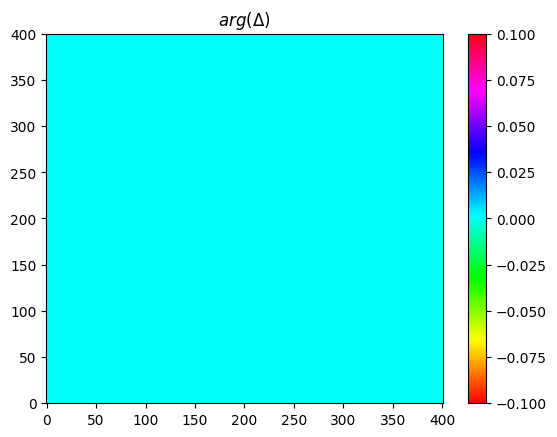

In [36]:
gamma_map['norm_delta'] = np.sqrt(gamma_map[4]**2 + gamma_map[5]**2)
gamma_map['phase_delta'] = (np.arctan2(gamma_map[5], gamma_map[4]))/ np.pi

pivot = gamma_map.pivot(index=1, columns=0, values='norm_delta')
print(pivot.isna().sum().sum())  # Count total NaNs
plt.title(r"$|\Delta|$")
plt.imshow(pivot, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar()
plt.show()


pivot = gamma_map.pivot(index=1, columns=0, values='phase_delta')
plt.title(r"$arg(\Delta)$")
plt.imshow(pivot, aspect='auto', origin='lower', cmap='hsv')
plt.colorbar()
plt.show()